In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
data = torch.load("../outputs/resnet_embeddings.pt")

features = data["features"]
labels = data["labels"]

print("Features shape:", features.shape)
print("Labels sample:", labels[:5])

Features shape: torch.Size([800, 2048])
Labels sample: [1, 1, 0, 1, 1]


In [3]:
if isinstance(features, torch.Tensor):
    features = features.cpu().numpy()

labels = np.array(labels)

print("Final shape:", features.shape)

Final shape: (800, 2048)


In [4]:
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

print("Class mapping:")
for i, cls in enumerate(le.classes_):
    print(f"{i} → {cls}")

Class mapping:
0 → 0
1 → 1


In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

In [6]:
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

In [7]:
acc1 = accuracy_score(labels_encoded, clusters)
acc2 = accuracy_score(labels_encoded, 1 - clusters)

accuracy = max(acc1, acc2)

print("Clustering Accuracy:", accuracy)

Clustering Accuracy: 0.96


In [8]:
cm = confusion_matrix(labels_encoded, clusters)

print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[ 10 390]
 [378  22]]


In [ ]:
# Visualize with t-SNE
pca = PCA(n_components=50)
X_pca = pca.fit_transform(X_scaled)

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_pca)

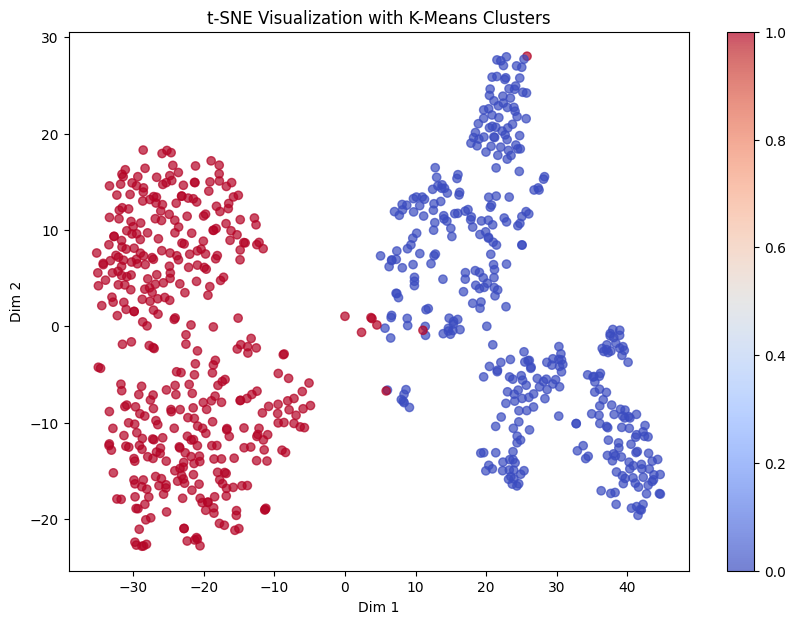

In [10]:
# Plot k-means clusters
plt.figure(figsize=(10, 7))

plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=clusters,
    cmap='coolwarm',
    alpha=0.7
)

plt.title("t-SNE Visualization with K-Means Clusters")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")

plt.colorbar()
plt.show()

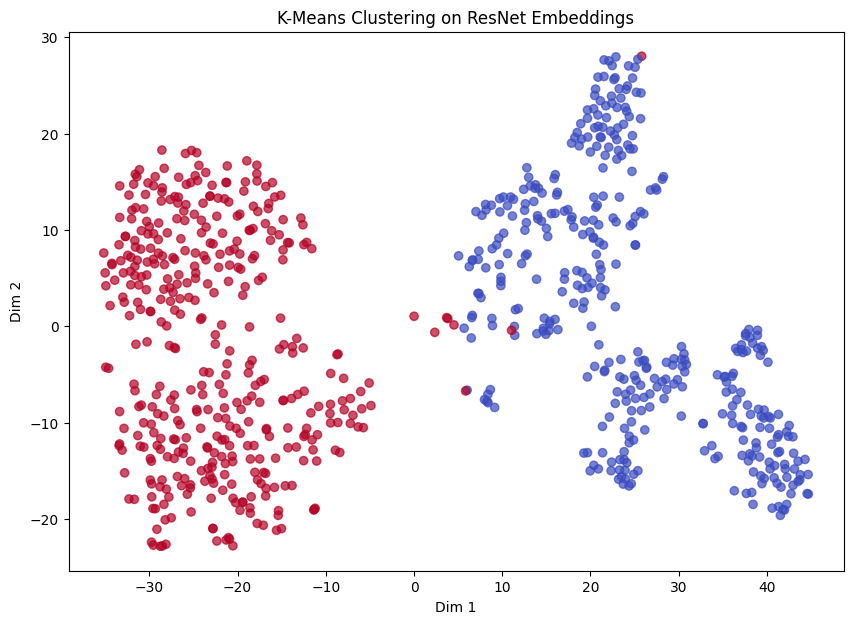

In [11]:
# Save the plot
os.makedirs("../outputs/plots", exist_ok=True)

plt.figure(figsize=(10, 7))

plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=clusters,
    cmap='coolwarm',
    alpha=0.7
)

plt.title("K-Means Clustering on ResNet Embeddings")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")

output_path = "../outputs/plots/kmeans_clusters.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')

plt.show()